## RL for PdM - PhD Thesis work
- V.2.1 17-Oct-2024: Change evaluation strategy.
- V.2.0 13-Oct-2024: Two environments - similar rewards.

**Datasets**
- NUAA_W1_0p229, NUAA_W3_0p12,  NUAA_W8_0p281
- PHM_C01_0p12,  PHM_C04_0p098, PHM_C06_0p13

**Approach**
- Create two environments: PHM and NUAA
- Train on NUAA-W1
- Evaluation: To demonstrate robustness
    - Down-sample other 5. 40 records each - from original 30K record files
    - Use these for validation
    - Keep tool-wear profile - run the model, record action and rewards gained
    - Compute average rewards
    - Plot action and rewards with title: Trained on XXX, Evaluated on XXX   
    - Use multiple data sets from each 3 + 3 = 6
- Additions:
    - Train on two NUAA and two PHM and test on rest 4
    - Add noise and Break-down
- Publish results

**Implementation Notes**
- Issue was RUL threshold should have some value and not 0

In [1]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

LAMBDA = 0.01
RANDOM_TOOL_START_OF_LIFE = 0.10 # 10% from the start
NO_ACTION = 0
REPLACE = 1

# Information arrays 
a_time = []

a_cost = []
a_replacements = []
a_time_since_last_replacement = []

class MillingTool_Env_NUAA(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 4}

    def __init__(self, records=0, env_type = '', rul_threshold=0.0):
        print(f' ******** Env. v.3 ******** {env_type} Milling tool environment initiatlized. Potential records {records}. RUL threshold {rul_threshold:4.3f}')
        # Initialize
        self.a_rewards = []
        self.a_actions = []
        self.a_action_recommended = []
        self.a_rul = []
        
        self.df = None
        self.current_time_step = 0
        self.records = records
        self.reward = 0.0
        self.maintenance_cost = 0.0
        self.replacement_events = 0
        self.time_since_last_replacement = 0
        
        self.rul_threshold = rul_threshold # Usually 5% from 0.0 i.e. 95th percentile record value from the very end 
        
        # Observation vector: ['timestamp', 'vibration_x', 'vibration_y', 'force_z', 'tool_wear', 'RUL', 'ACTION_CODE']
        # PHM Dataset:  force_x	     force_y	force_z	    vibration_x	vibration_y	vibration_z	           
        # NUAA Dataset: axial_force	            force_z     vibration_x	vibration_y vibration1	vibration2	

        high = np.array(
            [
                1.0,          # Max. axial_force
                1.0,          # Max. force_z
                1.0,          # Max. vibration_x
                1.0,          # Max. vibration_y
                1.0,          # Max. vibration1
                1.0,          # Max. vibration2
            ],
            dtype=np.float32,
        )

        # observation space lower limits
        low = np.array(
            [
                -1.0,          # Max. axial_force
                -1.0,          # Max. force_z
                -1.0,          # Max. vibration_x
                -1.0,          # Max. vibration_y
                -1.0,          # Max. vibration1
                -1.0,          # Max. vibration2
            ],
            dtype=np.float32,
        )
        
        self.observation_space = spaces.Box(low, high, dtype=np.float32)

        # Actions - Normal, L1-maintenance, L2-maintenance, Replace
        self.action_space = spaces.Discrete(2)

    ## Add tool wear data-set
    def tool_wear_data(self, df):
        self.df = df
        self.records = len(df.index)
        print(f'\n - Milling tool environment: Tool wear data updated: {self.records}')
        
    ## Constructing Observations From Environment States
    # - Observations are needed for both ``reset`` and ``step``, 
    # - Create private method ``_get_obs`` that translates the environment’s state into an observation.
    # - One can additionally use _get_info (in step and reset) if some auxilliary info. needs to be sent - for e.g. Expert action or Reward      #   info. or even RUL
    def _get_observation(self):
        if (self.df is not None):
            obs_values = np.array([
                self.df.loc[self.current_time_step, 'axial_force'],
                self.df.loc[self.current_time_step, 'force_z'],
                self.df.loc[self.current_time_step, 'vibration_x'],
                self.df.loc[self.current_time_step, 'vibration_y'],
                self.df.loc[self.current_time_step, 'vibration1'],
                self.df.loc[self.current_time_step, 'vibration2']
            ], dtype=np.float32)
        else:
            obs_values = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
        
        observation = obs_values.flatten()
        return observation

    # Get the current RUL reading, note this is NOT part of the observation
    def _get_auxilliary_info(self):
        if (self.df is not None):
            # From database extract recommended action
            recommended_action = int(self.df.loc[self.current_time_step, 'ACTION_CODE'])
            rul = float(self.df.loc[self.current_time_step, 'RUL'])
        else:
            # No database - use dummy values
            recommended_action = 0
            rul = 0.0

        return recommended_action, rul
            
    ## Reset
    # 1. Called to initiate a new episode and when 'Done'
    # 2. Assume that the ``step`` method will not be called before ``reset``
    # 3. Recommended to use RNG ``self.np_random`` provided by base class
    # 4. ** Important ** Must call ``super().reset(seed=seed)`` to correctly seed the RNG -- once done, we can randomly set the
    # state of our environment. In our case, we randomly choose the agent’s spatial location of "tool wear" 
    # 5. Must return a tuple of the *initial* observation - use ``_get_observation`` 

    def reset(self, seed=None, options=None):
        # print(' - reset')
        # We need the following line to seed self.np_random
        super().reset(seed=seed)

        # Choose the tool wear at a random time (spatial) location from a uniformly random distribution
        # self.current_time_step = np.random.randint(0, int(RANDOM_TOOL_START_OF_LIFE * self.records), 1, dtype=int)
        self.current_time_step = 0
        self.a_rewards = []
        self.a_actions = []
        self.a_action_recommended = []
        self.a_rul = []

        recommended_action, self.rul = self._get_auxilliary_info()
        observation = self._get_observation()
        info = {'reset':'Reset'}
        
        return observation, info

    ## Step
    # 1. Method the logic environment.
    # 2. Accepts an ``action``, computes the state of the environment **after** applying that action
    # 3. returns the 5-tuple ``(observation, reward, terminated, truncated, info)``
    # 4. Once the new state of the environment has been computed - check terminal state / set rewards
    # 5. To gather ``observation`` and ``info``, we can use of ``_get_obs`` and ``_get_info``:

    def step(self, action):
        # print(f' - step {action}')
        terminated = False
        self.reward = reward = 0.0
        info = {'Step':'-'}
        # Get auxilliary info: current RUL reading (note this is NOT part of the observation) and the expert's recommended action
        recommended_action, self.rul = self._get_auxilliary_info()
        self.maintenance_cost = 0.0
        self.replacement_events += 0
        
        if self.current_time_step >= self.records:
            terminated = done = True
            info = {'Step':'EOF'}
        elif self.rul <= self.rul_threshold: # Less-than-equal 0 (or near zero)
            terminated = done = True            
            info = {'Step':'RUL threshold crossed'}
        elif action == NO_ACTION: # Normal state
            reward = 1
            self.current_time_step += 1
            # 1% reduction in life
            self.maintenance_cost += 0.1
            info = {'Step':'None'}
        elif action == REPLACE:
            reward = -100
            self.current_time_step += 1
            # Replace the tool - reset to begining - but to a random position in the first 10% time-steps 
            self.maintenance_cost += 10.0
            self.replacement_events += 1
            self.time_since_last_replacement = self.current_time_step
            info = {'Step':'* REPLACE *'}

        # Action taken, set reward    
        # self.reward = (self.current_time_step + 1) / (self.maintenance_cost+LAMBDA)
        # self.reward = self.reward / 1e3 

        self.reward += reward
            
        # Information arrays 
        self.a_rewards.append(self.reward)
        self.a_action_recommended.append(recommended_action)
        self.a_rul.append(self.rul)
        self.a_actions.append(action)
        
        a_time.append(self.current_time_step)
        a_cost.append(self.maintenance_cost)
        a_replacements.append(self.replacement_events)
        a_time_since_last_replacement.append(self.time_since_last_replacement)
        
        # Action taken, reward set for that action, now take in next observation
        reward = float(self.reward)
        observation = self._get_observation()
        
        if self.render_mode == "human":
            print('{0:<20} | RUL: {1:>8.2f} | Cost: {2:>8.2f} | Reward: {3:>12.3f}'.format(action_text, self.rul, self.maintenance_cost, self.reward))

        return observation, reward, terminated, False, info
        

In [2]:
import warnings
from tqdm import tqdm # Progress bar
from datetime import datetime
warnings.filterwarnings('ignore')

# General libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

# RL libraries
import gymnasium as gym
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3 import PPO, A2C
from stable_baselines3.ppo import MlpPolicy
from torch.utils.tensorboard import SummaryWriter

# Custom libraries
# import MT_environment
# from MT_environment import MillingTool_Env_PHM,  MillingTool_Env_NUAA 

from utilities import downsample, tool_wear_data

now = datetime.now()
dt_string = now.strftime("%d-%b-%Y  %H:%M:%S")

In [3]:
# # from MT_environment import MillingTool_Env_PHM,  MillingTool_Env_NUAA 
# from importlib import reload
# reload(MT_environment)

In [4]:
datasets = {'NUAA_W1':['NUAA_W1_0p229.csv', 0.229], 'NUAA_W3':['NUAA_W3_0p12.csv', 0.12], 'NUAA_W8':['NUAA_W8_0p281.csv', 0.281],
           'PHM_C01':['PHM_C01_0p12.csv', 0.12],  'PHM_C04':['PHM_C04_0p098.csv', 0.12],  'PHM_C06':['PHM_C06_0p13.csv', 0.12]}

In [5]:
# NUAA_W1_0p229.csv, NUAA_W3_0p12.csv,  NUAA_W8_0p281.csv
# PHM_C01_0p12.csv,  PHM_C04_0p098.csv, PHM_C06_0p13.csv

In [6]:
ENV_TYPE = 'PHM'
TRAINING_DATA = 'PHM_C01'
EVALUATION_DATA = 'PHM_C01'

if ENV_TYPE == 'NUAA':
    DATA_FILE = datasets[TRAINING_DATA][0]
    WEAR_THRESHOLD = datasets[TRAINING_DATA][1]
    TEST_DATA = datasets[EVALUATION_DATA][0]
    TEST_WEAR_THRESHOLD = datasets[EVALUATION_DATA][1]
else:
    DATA_FILE = datasets[TRAINING_DATA][0]
    WEAR_THRESHOLD = datasets[TRAINING_DATA][1]
    TEST_DATA = datasets[EVALUATION_DATA][0]
    TEST_WEAR_THRESHOLD = datasets[EVALUATION_DATA][1]

SAMPLING_RATE = 5
ADD_NOISE = 0

ALGO = 'PPO'
EPISODES = 100
BATCH_SIZE = 16
EVALUATION_ROUNDS = 20

PRETRAINED_MODEL = False # If True load model. If False save as model_file 
TENSOR_BOARD = True

PATH = 'D:/ResearchLab/IRL/IRL_for_PdM'
DATA_PATH = f'{PATH}/Data/Training_datasets'
DATA_FILE = f'{DATA_PATH}/{DATA_FILE}'
# MODEL_FILE = f'{PATH}/models/Agent_{ENV_TYPE}_{ALGO}'
MODEL_FILE = f'{PATH}/models/PdM_Agent'
# LOG_PATH = f'{PATH}/tensorboard/'
LOG_PATH = f'{PATH}/tensorboard/{ENV_TYPE}/'

writer = SummaryWriter(LOG_PATH) if TENSOR_BOARD else None 
print(f'Data set: {DATA_FILE}, Threshold: {WEAR_THRESHOLD}')
print(f'Tensorboard logging to {LOG_PATH}')

Data set: D:/ResearchLab/IRL/IRL_for_PdM/Data/Training_datasets/PHM_C01_0p12.csv, Threshold: 0.12
Tensorboard logging to D:/ResearchLab/IRL/IRL_for_PdM/tensorboard/PHM/


- Down-sampling. Input data records: 1022. Sampling rate: 5. Expected rows 204.    Down-sampled to 205 rows.


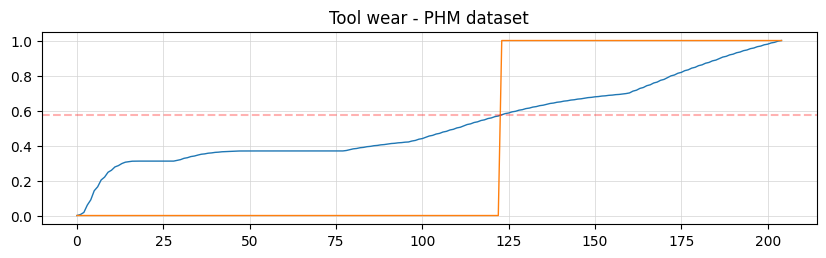

In [7]:
tool_wear, action_code, WEAR_THRESHOLD_NORMALIZED, df_train = tool_wear_data(
    env_type = ENV_TYPE, data_file=DATA_FILE, wear_threshold = WEAR_THRESHOLD,
    normalize=True, add_noise=ADD_NOISE, sampling_rate = SAMPLING_RATE)

records = len(df_train.index)
MILLING_OPERATIONS_MAX = records

In [8]:
# rul_threshold_record = int(0.95 * records)
rul_threshold_record_train = df_train.loc[df_train['tool_wear'] >= WEAR_THRESHOLD_NORMALIZED].index[0]
rul_threshold_train = df_train.loc[df_train.index[rul_threshold_record_train], 'RUL']
print(f'Tool failure RUL threshold at time {rul_threshold_record_train} is {rul_threshold_train:3.3f}')

Tool failure RUL threshold at time 123 is 0.424


## 1. Predictive maintenance environment

In [9]:
from stable_baselines3.common.env_checker import check_env

print(f' - Model is pre-trained on NUAA W1 data.\n - Environment being created on {ENV_TYPE}.')
gym.register(
    id = 'custom/MillingToolEnv-v0',
    entry_point = MillingTool_Env_NUAA if ENV_TYPE == 'NUAA' else MillingTool_Env_PHM,
    max_episode_steps = MILLING_OPERATIONS_MAX,)

mt_env = gym.make('custom/MillingToolEnv-v0', records=records, env_type = ENV_TYPE, rul_threshold=rul_threshold_train)
mt_env.tool_wear_data(df_train)
# Check env. formation 
# check_env(mt_env)

 - Model is pre-trained on NUAA W1 data.
 - Environment being created on PHM.


NameError: name 'MillingTool_Env_PHM' is not defined

In [ ]:
plt.figure(figsize=(10, 2.5))
plt.plot(mt_env.a_rul)
# plt.plot(df_train['tool_wear'])
plt.plot(df_train['RUL'])
plt.title('Training Env. a_rul[]')
plt.axhline(y = rul_threshold_train, color = 'b', linestyle = '--', alpha=0.3) 
plt.axhline(y = WEAR_THRESHOLD_NORMALIZED, color = 'r', linestyle = '--', alpha=0.3) 
plt.show()

## 2. Train the PdM Agent -or- load pre-trained model

In [ ]:
if ALGO == 'PPO':
    if TENSOR_BOARD:
        expert_ppo = PPO('MlpPolicy', env=mt_env, tensorboard_log=LOG_PATH)
    else:
        expert_ppo = PPO('MlpPolicy', env=mt_env)
    
    if not PRETRAINED_MODEL:
        print(f'- Training a *NEW* {ALGO} Expert model...')
        expert_ppo.learn(EPISODES)
        print(f'- Saving Expert model in {MODEL_FILE}')
        expert_ppo.save(MODEL_FILE)
    else:
        print(f'- Loading pre-tranined {ALGO} Expert model from {MODEL_FILE}')
        expert_ppo = PPO.load(MODEL_FILE)
elif ALGO == 'A2C':
    if TENSOR_BOARD:
        expert_a2c = A2C('MlpPolicy', env=mt_env, tensorboard_log=LOG_PATH)
    else:
        expert_a2c = A2C('MlpPolicy', env=mt_env)
    
    if not PRETRAINED_MODEL:
        print(f'- Training a *NEW* {ALGO} Expert model...')
        expert_a2c.learn(EPISODES)
        print(f'- Saving Expert model in {MODEL_FILE}')
        expert_a2c.save(MODEL_FILE)
    else:
        print(f'- Loading pre-tranined {ALGO} Expert model from {MODEL_FILE}')
        expert_a2c = A2C.load(MODEL_FILE)

In [ ]:
plt.figure(figsize=(10, 2.5))
# plt.plot(mt_env.a_rul, 'b')
plt.plot(mt_env.a_rewards, '.', alpha=0.3)
# plt.plot(df_train['tool_wear'])
# plt.plot(df_test['RUL'])
plt.title('Training RUL')
plt.axhline(y = rul_threshold_train, color = 'b', linestyle = '--', alpha=0.3) 
plt.axhline(y = WEAR_THRESHOLD_NORMALIZED, color = 'r', linestyle = '--', alpha=0.3) 
plt.show()

plt.figure(figsize=(10, 2.5))
plt.plot(mt_env.a_actions, alpha=0.7)
plt.plot(mt_env.a_action_recommended, alpha=0.7)
# plt.plot(df_train['tool_wear'])
# plt.plot(df_test['RUL'])
plt.title('Training RUL')
plt.axhline(y = rul_threshold_train, color = 'b', linestyle = '--', alpha=0.3) 
plt.axhline(y = WEAR_THRESHOLD_NORMALIZED, color = 'r', linestyle = '--', alpha=0.3) 
plt.show()

# EVALUATION PHASE

- Down-sampling. Input data records: 1001. Sampling rate: 40. Expected rows 25.    Down-sampled to 26 rows.


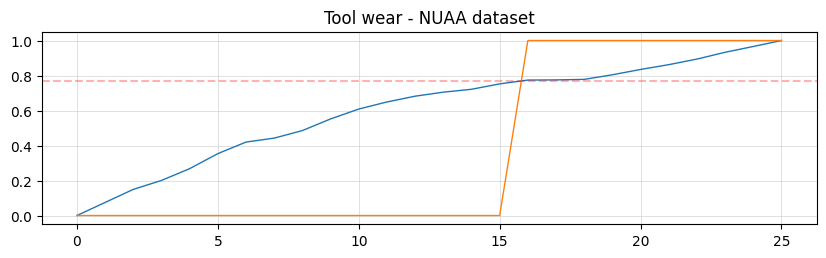

16
TRAINING: Tool-wear: 125 is 0.768, RUL: 125 is 0.231
TESTING:  Tool-wear: 16 is 0.768, RUL: 16 is 0.226


In [93]:
# ENV_TYPE = 'PHM'
TEST_DATA = datasets[EVALUATION_DATA][0]
TEST_FILE = f'{DATA_PATH}/{TEST_DATA}'
PATH = 'D:/ResearchLab/IRL/IRL_for_PdM/Data/Original_datasets/'
SAMPLING_RATE = 40
ADD_NOISE = 0

tool_wear, action_code, WEAR_THRESHOLD_NORMALIZED, df_test = tool_wear_data(
    env_type = ENV_TYPE, data_file=TEST_FILE, wear_threshold = TEST_WEAR_THRESHOLD,
    normalize=True, add_noise=ADD_NOISE, sampling_rate = SAMPLING_RATE)

n_test_records = len(df_test.index)
MILLING_OPERATIONS_MAX = n_test_records

# Compute RUL threshold for the test environment
# rul_threshold_record = int(0.95 * records)
rul_threshold_record_test = df_test.loc[df_test['tool_wear'] >= WEAR_THRESHOLD_NORMALIZED].index[0]
print(rul_threshold_record_test)
rul_threshold_test = df_test.loc[df_test.index[rul_threshold_record_test], 'RUL']
# print(f'Tool failure RUL threshold at time {rul_threshold_record_test} is {rul_threshold_test:3.3f}')

print(f'TRAINING: Tool-wear: {rul_threshold_record_train} is {WEAR_THRESHOLD_NORMALIZED:3.3f}, RUL: {rul_threshold_record_train} is {rul_threshold_train:3.3f}')
print(f'TESTING:  Tool-wear: {rul_threshold_record_test} is {WEAR_THRESHOLD_NORMALIZED:3.3f}, RUL: {rul_threshold_record_test} is {rul_threshold_test:3.3f}')

In [94]:
# gym.register(
#     id = 'custom/MillingToolEnv-v0',
#     entry_point = MillingTool_Env_NUAA if ENV_TYPE == 'NUAA' else MillingTool_Env_PHM,
#     max_episode_steps = MILLING_OPERATIONS_MAX,)

mt_test_env = gym.make('custom/MillingToolEnv-v0', records=n_test_records, env_type = ENV_TYPE, rul_threshold=rul_threshold_test)
mt_test_env.tool_wear_data(df_test)

 ******** Env. v.3 ******** NUAA Milling tool environment initiatlized. Potential records 26. RUL threshold 0.226

 - Milling tool environment: Tool wear data updated: 26


In [95]:
obsv = mt_test_env.reset()
# During reset a tuple is returned. So take the state only. When the step() is called it properly returns only the state so obsv will work
obsv = obsv[0]

eval_rewards = []
eval_action = []
eval_o = []
for i in range(n_test_records):
    action, _state = expert_a2c.predict(obsv)
    if (action == 1): 
        print('Actions: Type: ', type(action), ' Value: ',  action)
    obsv, reward, done, info, _ = mt_test_env.step(action)
    eval_o.append(obsv[0])
    eval_rewards.append(reward)
    eval_action.append(action)

plt.figure(figsize=(10, 2))
plt.plot(eval_o)
plt.plot(eval_action, 'r')
plt.title('eval -- axial_force')
plt.show()

AttributeError: 'MillingTool_Env_NUAA' object has no attribute 'reward'

In [64]:
print('stop')

stop


In [65]:
# eval_rewards = np.around(eval_rewards, 3).tolist()
# print(eval_rewards[-10:])
# print(eval_action[-10:])

In [66]:
# mt_env.time_since_last_replacement

In [67]:
# df_raw = pd.read_csv(TEST_FILE)
# tool_wear = df_raw['tool_wear']
# plt.figure(figsize=(10, 2.5))
# plt.plot(tool_wear, linewidth=1)
# plt.axhline(y = WEAR_THRESHOLD, color = 'r', linestyle = '--', alpha=0.3) 
# plt.title(f'Agent NUAA W1. Evaluation on PHM dataset - {TEST_DATA}')
# # plt.title(f'Agent trained on NUAA W1. Evaluation on PHM dataset - {TEST_FILE}')
# plt.grid(color='lightgray', linestyle='-', linewidth=0.5)
# plt.show()

# plt.figure(figsize=(10, 2.5))
# plt.plot(eval_rewards, linewidth=1)
# plt.plot(eval_action, color = 'r', linewidth=0.5)
# plt.title(f'Rewards')
# plt.grid(color='lightgray', linestyle='-', linewidth=0.5)
# plt.show()

In [68]:
# print('-'*120)
# print(' **** Reinforcement Learning for Predictive Maintenance ****')
# print('-'*120)

# print(dt_string)
# print(f'Algo. {ALGO} - Episodes:  {EPISODES}')

# if ALGO == 'PPO':
#     reward_ppo, _ = evaluate_policy(expert_ppo, mt_env, EVALUATION_ROUNDS)
#     print(f'PPO agent: {reward_ppo:5.2f}')
# elif ALGO == 'A2C':
#     reward_a2c, _ = evaluate_policy(expert_a2c, mt_env, EVALUATION_ROUNDS)
#     print(f'A2C agent: {reward_a2c:5.2f}')

In [69]:
# now = datetime.now()
# dt_string = now.strftime('%d-%b-%Y')

In [70]:
# import csv
# from pathlib import Path

# data_file_name = (DATA_FILE.split('/')[-1])

# results=[now.strftime('%d-%b-%Y'), now.strftime('%H:%M:%S'), ALGO, ENV_TYPE, data_file_name, EVALUATION_ROUNDS, round(reward_a2c, 3)]
# print(results)

# # Check if reports file exists 
# report_file = Path('Report.csv')
# if not report_file.is_file():
#     print('New report file created.')
#     report_columns=['Date', 'Time', 'Algo', 'Data-set', 'Data file', 'Evaluation rounds', 'Rewards']
#     with open(report_file, 'w', newline='') as f:
#         writer = csv.writer(f)
#         writer.writerow(report_columns)
# else:
#     print('Results added to report file.')
#     with open(report_file, 'a', newline='') as f:
#         writer = csv.writer(f)
#         writer.writerow(results)

## Generate Evaluation Data sets

In [71]:
# ENV_TYPE = 'PHM'
# PATH = 'D:/ResearchLab/IRL/IRL_for_PdM/Data/Original_datasets/'
# FILE = 'PHM_C01_0p12_original'
# DATA_FILE = f'{PATH}{FILE}.csv'
# TEST_FILE = f'{PATH}{FILE}_TEST.csv'
# WEAR_THRESHOLD = 0.12
# SAMPLING_RATE = 35*25
# ADD_NOISE = 0

# tool_wear, action_code, WEAR_THRESHOLD_NORMALIZED, df_test = tool_wear_data(
#     env_type = ENV_TYPE, data_file=DATA_FILE, wear_threshold = WEAR_THRESHOLD,
#     normalize=False, add_noise=ADD_NOISE, sampling_rate = SAMPLING_RATE)

# records = len(df_test.index)
# MILLING_OPERATIONS_MAX = records

# rul_threshold_record = int(0.95 * records)
# rul_threshold = df_train.loc[df_test.index[rul_threshold_record], 'RUL']
# print(f'Tool failure RUL threshold at time {rul_threshold_record} is {rul_threshold:3.3f}')
# df_test.to_csv(TEST_FILE)